   k    inertia  silhouette
0  2  65561.442       0.231
1  3  55151.717       0.267
2  4  46559.864       0.290
3  5  42214.686       0.206
4  6  38731.562       0.230
5  7  35913.593       0.225
6  8  33741.017       0.226


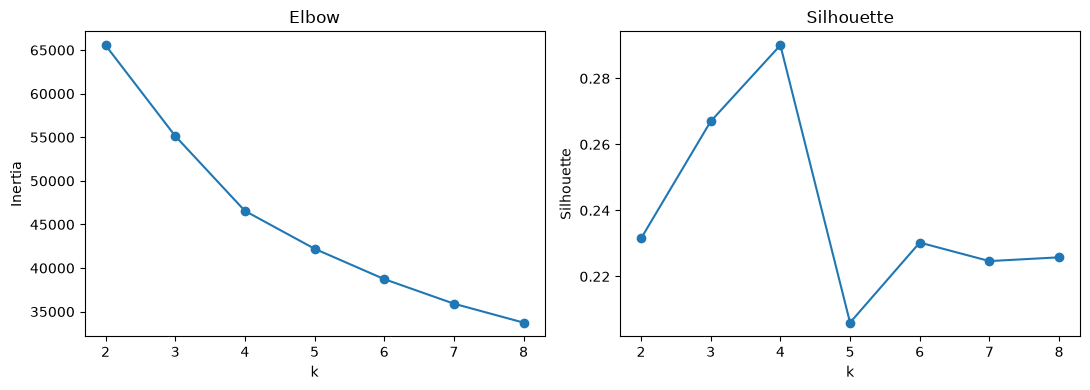

In [1]:
import pandas as pd, numpy as np, os, json, joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv("../data/processed/features_dataset.csv")
df["log_salary"] = np.log1p(df["estimated_annual_salary_lpa"])
feats = ["years_experience", "log_salary", "employability_score", "certifications_count",
         "education_ord", "in_demand_skill_flag_bin", "uses_generative_ai_tools_bin"]
Xs = StandardScaler().fit_transform(df[feats])

ks, inertia, sil = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_, sample_size=5000, random_state=42))
print(pd.DataFrame({"k": ks, "inertia": inertia, "silhouette": sil}).round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set(xlabel="k", ylabel="Inertia", title="Elbow")
ax[1].plot(ks, sil, "o-"); ax[1].set(xlabel="k", ylabel="Silhouette", title="Silhouette")
plt.tight_layout(); plt.savefig("../outputs/figures/11_kmeans_k_selection.png", dpi=150); plt.show()

         size  years  salary_lpa  employability  certs  education  in_demand  \
cluster                                                                        
0        5788   3.15        9.10          44.87   1.32       2.08       0.00   
1        2772  13.44       37.60          59.27   2.12       2.13       0.10   
2        1364   5.17       12.40          40.30   1.47       2.10       0.11   
3        2076   4.52       14.05          53.61   1.43       2.08       1.00   

         genai  
cluster         
0         1.00  
1         0.97  
2         0.00  
3         1.00  
seniority_level  Associate  Director+  Entry-level  Lead/Principal  \
cluster                                                              
0                     1967          0         2200               1   
1                        5        452            0             869   
2                      334          7          392              98   
3                      579          0          593              42 

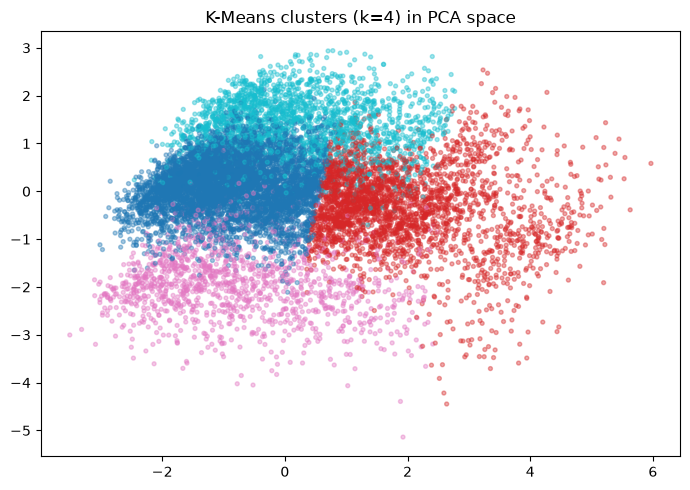

In [2]:
K = 4   # change after reviewing Cell 1
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)
df["cluster"] = km.labels_

profile = df.groupby("cluster").agg(
    size=("profile_id", "count"),
    years=("years_experience", "mean"),
    salary_lpa=("estimated_annual_salary_lpa", "median"),
    employability=("employability_score", "mean"),
    certs=("certifications_count", "mean"),
    education=("education_ord", "mean"),
    in_demand=("in_demand_skill_flag_bin", "mean"),
    genai=("uses_generative_ai_tools_bin", "mean")).round(2)
print(profile)
print(pd.crosstab(df["cluster"], df["seniority_level"]))

pcs = PCA(n_components=2, random_state=42).fit_transform(Xs)
plt.figure(figsize=(7, 5))
plt.scatter(pcs[:, 0], pcs[:, 1], c=df["cluster"], cmap="tab10", alpha=0.4, s=8)
plt.title(f"K-Means clusters (k={K}) in PCA space")
plt.tight_layout(); plt.savefig("../outputs/figures/12_kmeans_pca.png", dpi=150); plt.show()

In [4]:
os.makedirs("../models", exist_ok=True); os.makedirs("../outputs/metrics", exist_ok=True)
joblib.dump(km, "../models/kmeans_model.pkl")
json.dump({"k": K, "silhouette": float(silhouette_score(Xs, km.labels_, sample_size=5000, random_state=42)),
           "inertia": float(km.inertia_)}, open("../outputs/metrics/kmeans_metrics.json", "w"), indent=2)
profile.to_csv("../outputs/metrics/kmeans_profiles.csv")

In [5]:
from sklearn.metrics import adjusted_rand_score
base = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xs).labels_
for s in [1, 2, 3]:
    other = KMeans(n_clusters=4, n_init=10, random_state=s).fit(Xs).labels_
    print(s, round(adjusted_rand_score(base, other), 3))

1 1.0
2 1.0
3 1.0
